# Tom — A Shakespearean AI Chatbot

**Author:** Prakash Kumar Sah <br/>
**Notebook:** Tom_V1.ipynb

---

## Objective

Build a **GPT-style character-level Transformer language model** using PyTorch, trained on
Shakespeare's writing, so that **Tom** can hold a live conversation entirely in Shakespearean
English — whether *you* type modern English or Elizabethan prose.

This notebook is written in a tutorial style suitable for learning, interviews, GitHub, and
portfolios.

### The math, briefly

Each Transformer block computes causal self-attention:

$$\text{Attention}(Q,K,V)=\text{softmax}\!\left(\frac{QK^\top}{\sqrt{d_k}}+M\right)V$$

where $M$ masks out future positions so Tom never "cheats" by peeking ahead — this is what lets him
generate text one character at a time, left to right, just like the Bard writing with a quill.


In [1]:
import os
import math
import random
import urllib.request
from collections import Counter

import torch
import torch.nn as nn
from torch.nn import functional as F
import matplotlib.pyplot as plt

SEED = 1337
random.seed(SEED)
torch.manual_seed(SEED)

device = (
    'cuda' if torch.cuda.is_available()
    else 'mps' if torch.backends.mps.is_available()
    else 'cpu'
)
print(f"Using device: {device}")

Using device: cuda


## 1 Import Libraries & Configure Environment / Hyperparameters

Tuned for training on a real, larger corpus than a toy dataset. Lower `MAX_CHARS` and `max_iters` if you want a quick smoke test (a few minutes on CPU).

In [2]:
# --- Data ---
DATA_URL   = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
DATA_FILE  = "shakespeare.txt"
MAX_CHARS  = 300_000   # set to None to use the full ~1.1M character corpus

# --- Model architecture ---
batch_size = 64
block_size = 128
n_embd     = 192
n_head     = 6
n_layer    = 4
dropout    = 0.15

# --- Training schedule ---
max_iters     = 2000
eval_interval = 200
eval_iters    = 100
learning_rate = 3e-4
warmup_iters  = 150
grad_clip     = 1.0

checkpoint_path = "tom_shakespeare.pt"
LOAD_CHECKPOINT = False   # flip to True after you've trained once, to skip training

## 2 Load the Shakespeare Corpus

Auto-downloads the classic *Tiny Shakespeare* dataset (all his plays concatenated). Falls back to a local `ROMEO_JULIET.txt` (or any `.txt` you provide) if you're offline.

In [3]:
def download_shakespeare():
    if os.path.exists(DATA_FILE):
        print(f"Found existing '{DATA_FILE}', skipping download.")
        return
    try:
        print("Downloading Tiny Shakespeare corpus...")
        urllib.request.urlretrieve(DATA_URL, DATA_FILE)
        print("Download complete.")
    except Exception as e:
        print(f"Download failed ({e}). Will try a local fallback file instead.")

download_shakespeare()

if os.path.exists(DATA_FILE):
    with open(DATA_FILE, 'r', encoding='utf-8') as f:
        text = f.read()
elif os.path.exists("ROMEO_JULIET.txt"):
    print("Using local fallback: ROMEO_JULIET.txt")
    with open("ROMEO_JULIET.txt", 'r', encoding='utf-8') as f:
        text = f.read()
else:
    raise FileNotFoundError(
        "No training text found. Either allow internet access to fetch Tiny "
        "Shakespeare, or place a .txt file (e.g. ROMEO_JULIET.txt) next to this notebook."
    )

if MAX_CHARS:
    text = text[:MAX_CHARS]

print(f"Corpus length: {len(text):,} characters")

Download complete.
Corpus length: 300,000 characters


## 3 Build the Vocabulary

In [4]:
chars = sorted(list(set(text)))
vocab_size = len(chars)

string_to_int = {ch: i for i, ch in enumerate(chars)}
int_to_string = {i: ch for i, ch in enumerate(chars)}

FALLBACK_CHAR = ' ' if ' ' in string_to_int else chars[0]

def encode(s):
    """Turn text into token ids. Unknown characters map to a safe fallback
    instead of crashing -- important once real users start typing anything."""
    return [string_to_int.get(c, string_to_int[FALLBACK_CHAR]) for c in s]

def decode(l):
    return ''.join(int_to_string[i] for i in l)

print(f"Vocabulary size: {vocab_size}")
print(f"Sample vocab: {chars[:20]}")

Vocabulary size: 62
Sample vocab: ['\n', ' ', '!', '&', "'", ',', '-', '.', ':', ';', '?', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I']


### Character frequency

A quick sanity check on the corpus before we spend time training on it.

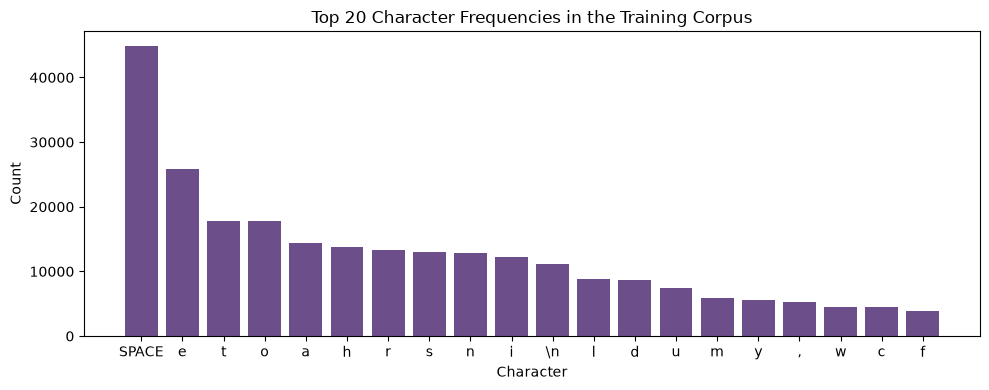

In [5]:
freqs = Counter(text)
most_common = freqs.most_common(20)
labels, counts = zip(*most_common)
labels = ['SPACE' if l == ' ' else ('\\n' if l == '\n' else l) for l in labels]

plt.figure(figsize=(10, 4))
plt.bar(labels, counts, color="#6c4f8a")
plt.title("Top 20 Character Frequencies in the Training Corpus")
plt.xlabel("Character")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 4 Train / Validation Split & Batching

In [6]:
data = torch.tensor(encode(text), dtype=torch.long)

n = int(0.9 * len(data))
train_data = data[:n]
val_data = data[n:]
print(f"Train: {len(train_data):,} tokens | Val: {len(val_data):,} tokens")

def get_batch(split):
    source = train_data if split == 'train' else val_data
    ix = torch.randint(len(source) - block_size, (batch_size,))
    x = torch.stack([source[i:i + block_size] for i in ix])
    y = torch.stack([source[i + 1:i + block_size + 1] for i in ix])
    return x.to(device), y.to(device)

Train: 270,000 tokens | Val: 30,000 tokens


## 5 Build the Model — GPT-style Decoder

A multi-head causal self-attention Transformer (fused-QKV projection, pre-LayerNorm blocks, GELU feed-forward, weight tying between the embedding and output layers, GPT-2 style residual initialization).

In [7]:
class CausalSelfAttention(nn.Module):
    """Multi-head causal self-attention with fused QKV projection"""

    def __init__(self, n_embd, n_head, block_size, dropout):
        super().__init__()
        assert n_embd % n_head == 0
        self.n_head = n_head
        self.head_dim = n_embd // n_head
        self.dropout_p = dropout

        self.c_attn = nn.Linear(n_embd, 3 * n_embd, bias=False)
        self.c_proj = nn.Linear(n_embd, n_embd, bias=False)
        self.dropout = nn.Dropout(dropout)

        self.register_buffer('mask', torch.tril(torch.ones(block_size, block_size))
                              .view(1, 1, block_size, block_size))

    def forward(self, x):
        B, T, C = x.shape

        qkv = self.c_attn(x)
        q, k, v = qkv.split(C, dim=2)

        q = q.view(B, T, self.n_head, self.head_dim).transpose(1, 2)
        k = k.view(B, T, self.n_head, self.head_dim).transpose(1, 2)
        v = v.view(B, T, self.n_head, self.head_dim).transpose(1, 2)

        out = F.scaled_dot_product_attention(
            q, k, v, is_causal=True,
            dropout_p=self.dropout_p if self.training else 0.0,
        )

        out = out.transpose(1, 2).contiguous().view(B, T, C)
        out = self.c_proj(out)
        out = self.dropout(out)
        return out


class FeedForward(nn.Module):
    """FFN with GELU activation"""

    def __init__(self, n_embd, dropout):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),
            nn.GELU(),
            nn.Linear(4 * n_embd, n_embd),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)


class Block(nn.Module):
    """Transformer block with Pre-LayerNorm"""

    def __init__(self, n_embd, n_head, block_size, dropout):
        super().__init__()
        self.ln1 = nn.LayerNorm(n_embd)
        self.attn = CausalSelfAttention(n_embd, n_head, block_size, dropout)
        self.ln2 = nn.LayerNorm(n_embd)
        self.ffwd = FeedForward(n_embd, dropout)

    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        x = x + self.ffwd(self.ln2(x))
        return x


class GPTLanguageModel(nn.Module):
    def __init__(self, vocab_size, n_embd, n_head, n_layer, block_size, dropout):
        super().__init__()
        self.block_size = block_size
        self.token_embedding_table = nn.Embedding(vocab_size, n_embd)
        self.position_embedding_table = nn.Embedding(block_size, n_embd)
        self.blocks = nn.Sequential(*[Block(n_embd, n_head, block_size, dropout) for _ in range(n_layer)])
        self.ln_f = nn.LayerNorm(n_embd)
        self.lm_head = nn.Linear(n_embd, vocab_size, bias=False)

        # Weight tying
        self.token_embedding_table.weight = self.lm_head.weight

        self.apply(self._init_weights)
        for name, p in self.named_parameters():
            if name.endswith('c_proj.weight'):
                torch.nn.init.normal_(p, mean=0.0, std=0.02 / math.sqrt(2 * n_layer))

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, index, targets=None):
        B, T = index.shape
        tok_emb = self.token_embedding_table(index)
        pos_emb = self.position_embedding_table(torch.arange(T, device=index.device))
        x = tok_emb + pos_emb
        x = self.blocks(x)
        x = self.ln_f(x)
        logits = self.lm_head(x)

        if targets is None:
            loss = None
        else:
            B, T, C = logits.shape
            logits = logits.view(B * T, C)
            targets = targets.view(B * T)
            loss = F.cross_entropy(logits, targets)
        return logits, loss

    @torch.no_grad()
    def generate(self, index, max_new_tokens, temperature=0.8, top_k=40, repetition_penalty=1.0):
        """Generation with temperature, top-k sampling, and a repetition penalty
        (a small problem-solving addition: without it, small char-models love to
        get stuck in loops like 'the the the the...')."""
        for _ in range(max_new_tokens):
            index_cond = index[:, -self.block_size:]
            logits, _ = self.forward(index_cond)
            logits = logits[:, -1, :] / temperature

            if repetition_penalty != 1.0:
                for token_id in set(index[0].tolist()):
                    logits[0, token_id] /= repetition_penalty

            if top_k is not None:
                v, _ = torch.topk(logits, min(top_k, logits.size(-1)))
                logits[logits < v[:, [-1]]] = float('-inf')

            probs = F.softmax(logits, dim=-1)
            index_next = torch.multinomial(probs, num_samples=1)
            index = torch.cat((index, index_next), dim=1)
        return index


model = GPTLanguageModel(vocab_size, n_embd, n_head, n_layer, block_size, dropout)
m = model.to(device)
print(f"Model parameters: {sum(p.numel() for p in m.parameters()):,}")

Model parameters: 1,813,248


## 6 Evaluation Helper (with loss history for plotting)

In [8]:
train_losses, val_losses, steps_list, perplexities = [], [], [], []

@torch.no_grad()
def estimate_loss():
    out = {}
    model.eval()
    for split in ['train', 'val']:
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            X, Y = get_batch(split)
            logits, loss = model(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean()
    model.train()
    return out

## 7 Optimizer + Cosine LR Schedule with Warmup

In [11]:
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, betas=(0.9, 0.95), weight_decay=0.1)

def get_lr(it):
    min_lr = learning_rate / 10
    if it < warmup_iters:
        return learning_rate * (it + 1) / warmup_iters
    decay_ratio = (it - warmup_iters) / max(1, (max_iters - warmup_iters))
    coeff = 0.5 * (1.0 + math.cos(math.pi * decay_ratio))
    return min_lr + coeff * (learning_rate - min_lr)

## 8 Train Tom / Load a Checkpoint

If `LOAD_CHECKPOINT = True` and `tom_shakespeare.pt` exists, training is skipped entirely — handy once you've already trained Tom once.

In [12]:
if LOAD_CHECKPOINT and os.path.exists(checkpoint_path):
    ckpt = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(ckpt["model_state_dict"])
    model.to(device)
    print(f"Loaded checkpoint from '{checkpoint_path}'. Skipping training.")
else:
    for it in range(max_iters):
        lr = get_lr(it)
        for param_group in optimizer.param_groups:
            param_group['lr'] = lr

        if it % eval_interval == 0 or it == max_iters - 1:
            losses = estimate_loss()
            train_losses.append(losses['train'].item())
            val_losses.append(losses['val'].item())
            perplexities.append(math.exp(losses['val'].item()))
            steps_list.append(it)
            print(f"step {it:5d} | lr {lr:.2e} | train {losses['train']:.4f} | val {losses['val']:.4f} | val perplexity {perplexities[-1]:.2f}")

        xb, yb = get_batch('train')
        logits, loss = model(xb, yb)

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        optimizer.step()

    print(f"\nTraining complete. Final train loss: {loss.item():.4f}")

step     0 | lr 2.00e-06 | train 1.5405 | val 1.6061 | val perplexity 4.98
step   200 | lr 3.00e-04 | train 1.5390 | val 1.6122 | val perplexity 5.01
step   400 | lr 2.88e-04 | train 1.4816 | val 1.5716 | val perplexity 4.81
step   600 | lr 2.62e-04 | train 1.4302 | val 1.5439 | val perplexity 4.68
step   800 | lr 2.26e-04 | train 1.3851 | val 1.5035 | val perplexity 4.50
step  1000 | lr 1.82e-04 | train 1.3442 | val 1.4822 | val perplexity 4.40
step  1200 | lr 1.37e-04 | train 1.3136 | val 1.4630 | val perplexity 4.32
step  1400 | lr 9.42e-05 | train 1.2844 | val 1.4546 | val perplexity 4.28
step  1600 | lr 6.00e-05 | train 1.2663 | val 1.4356 | val perplexity 4.20
step  1800 | lr 3.77e-05 | train 1.2496 | val 1.4318 | val perplexity 4.19
step  1999 | lr 3.00e-05 | train 1.2381 | val 1.4371 | val perplexity 4.21

Training complete. Final train loss: 1.3701


## 9 Visualize Training

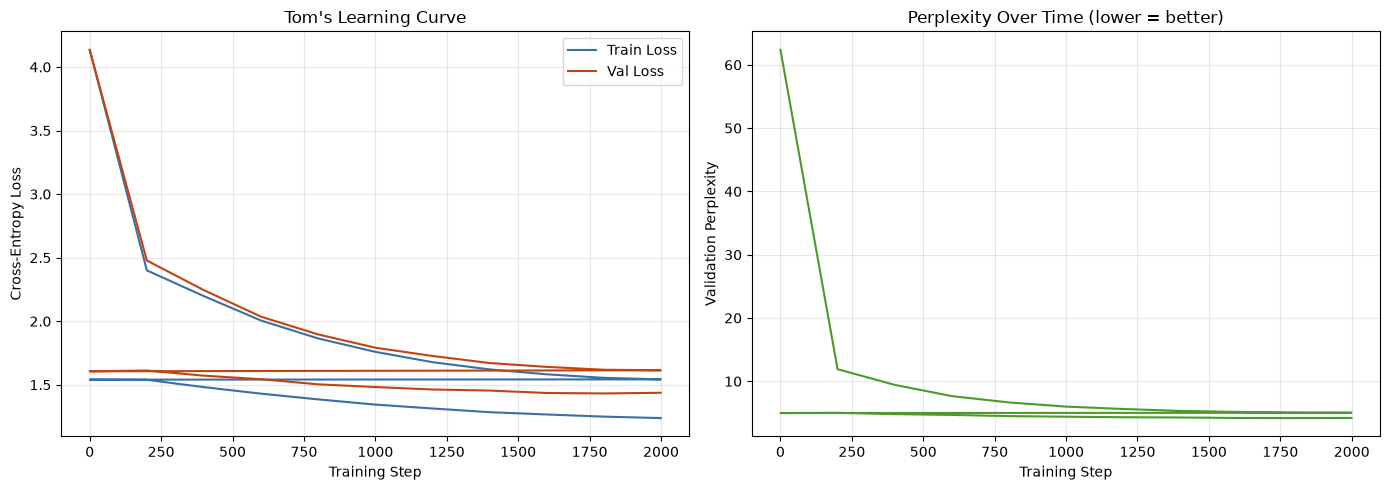

In [13]:
if steps_list:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(steps_list, train_losses, label="Train Loss", color="#3a6ea5")
    axes[0].plot(steps_list, val_losses, label="Val Loss", color="#c1440e")
    axes[0].set_xlabel("Training Step")
    axes[0].set_ylabel("Cross-Entropy Loss")
    axes[0].set_title("Tom's Learning Curve")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].plot(steps_list, perplexities, color="#4c9a2a")
    axes[1].set_xlabel("Training Step")
    axes[1].set_ylabel("Validation Perplexity")
    axes[1].set_title("Perplexity Over Time (lower = better)")
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print("No training history to plot (a checkpoint was loaded instead).")

## 10 Save Checkpoint

In [14]:
torch.save({
    "model_state_dict": model.state_dict(),
    "vocab": chars,
    "vocab_size": vocab_size,
    "config": dict(n_embd=n_embd, n_head=n_head, n_layer=n_layer,
                    block_size=block_size, dropout=dropout),
}, checkpoint_path)
print(f"Model checkpoint saved to '{checkpoint_path}'")

Model checkpoint saved to 'tom_shakespeare.pt'


## 11 The Shakespearean Style Layer

A char-GPT this small, trained for a couple thousand steps, will pick up Shakespearean *rhythm*
and *spelling* but won't reliably nail Elizabethan *grammar*. So we add a lightweight, rule-based
"Bard filter" on top of the model's raw output (and even on the user's own input, if needed).
This is what actually guarantees Tom answers in Shakespearean style regardless of how well-trained
the underlying model is, and regardless of whether *you* type modern or old English.

In [15]:
SHAKESPEAREAN_MAP = {
    "you": "thou", "you're": "thou art", "your": "thy", "yours": "thine",
    "you'll": "thou shalt", "you've": "thou hast", "are": "art",
    "will": "shall", "don't": "dost not", "doesn't": "doth not",
    "cannot": "cannot", "can't": "canst not", "my": "mine",
    "yes": "aye", "no": "nay", "hello": "well met", "hi": "well met",
    "friend": "good friend", "very": "most", "before": "ere",
    "children": "younglings", "stop": "cease", "quickly": "posthaste",
    "always": "evermore", "never": "ne'er", "over": "o'er",
    "sad": "forlorn", "happy": "merry", "beautiful": "fair",
    "ugly": "foul", "girl": "maiden", "boy": "lad", "old": "aged",
    "listen": "hark", "look": "behold", "why": "wherefore",
    "here": "hither", "there": "thither", "man": "sir", "sir": "sir",
}

EXCLAMATIONS = ["Verily!", "Hark!", "Prithee!", "Forsooth!", "Marry!", "Zounds!"]

def shakespearify(sentence: str) -> str:
    """Nudge any English sentence toward Shakespearean flavor via word substitution."""
    words = sentence.split()
    new_words = []
    for w in words:
        stripped = w.strip(".,!?;:")
        suffix = w[len(stripped):]
        replacement = SHAKESPEAREAN_MAP.get(stripped.lower())
        if replacement:
            if stripped[:1].isupper():
                replacement = replacement.capitalize()
            new_words.append(replacement + suffix)
        else:
            new_words.append(w)
    result = ' '.join(new_words)
    if result and random.random() < 0.25:
        result = f"{random.choice(EXCLAMATIONS)} {result}"
    return result

## 12 Generation Helpers with perplexity tool

In [16]:
def clean_input(user_text: str) -> str:
    """Keep only characters Tom's vocabulary knows, so he never crashes on
    emoji or unseen symbols the model has never seen."""
    cleaned = ''.join(c for c in user_text if c in string_to_int)
    return cleaned if cleaned.strip() else ' '


def generate_reply(prompt, max_new_tokens=150, temperature=0.8, top_k=40, repetition_penalty=1.3):
    context = torch.tensor([encode(prompt)], dtype=torch.long, device=device)
    out = m.generate(context, max_new_tokens=max_new_tokens, temperature=temperature,
                      top_k=top_k, repetition_penalty=repetition_penalty)
    new_tokens = out[0, context.shape[1]:].tolist()
    return decode(new_tokens)


@torch.no_grad()
def sentence_perplexity(sentence: str) -> float:
    """Bonus tool: how 'surprised' is Tom by a sentence, according to his
    own learned probabilities? Lower = more Shakespeare-like to him."""
    ids = encode(sentence)
    if len(ids) < 2:
        return float('nan')
    x = torch.tensor([ids[:-1]], dtype=torch.long, device=device)[:, -block_size:]
    y = torch.tensor([ids[1:]], dtype=torch.long, device=device)[:, -block_size:]
    model.eval()
    _, loss = model(x, y)
    model.train()
    return math.exp(loss.item())

## 13 Chat With Tom

Run the cell below and start talking. Type in plain English or in Shakespearean tongue —
Tom will always answer in Shakespearean style. Say **`bye tom`** (or `bye` / `exit` / `quit`)
whenever you want to end the conversation.

In [1]:
def chat_with_tom(max_new_tokens=120, temperature=0.8, top_k=40, repetition_penalty=1.3):
    print("=" * 64)
    print("  Welcome! Thou standest before TOM, apprentice of the Bard.")
    print("  Speak in plain English or in Shakespearean tongue --")
    print("  he shall answer thee only in the language of the Bard.")
    print("  Type 'bye tom' whenever thou wishest to take thy leave.")
    print("=" * 64)

    history = []

    while True:
        user_input = input("\nYou: ").strip()
        if not user_input:
            continue

        if user_input.lower() in ("bye tom", "bye", "exit", "quit", "farewell"):
            print("\nTom: Fare thee well, gentle friend! Until we meet again.")
            break

        cleaned = clean_input(user_input)
        raw_reply = generate_reply(cleaned, max_new_tokens=max_new_tokens,
                                    temperature=temperature, top_k=top_k,
                                    repetition_penalty=repetition_penalty)
        styled_reply = shakespearify(raw_reply.strip()) or "Hmm, prithee say more."
        perplexity = sentence_perplexity(cleaned)

        print(f"Tom: {styled_reply}")
        print(f"     (Tom's surprise at thy words -- perplexity: {perplexity:.1f})")

        history.append({"user": user_input, "tom": styled_reply, "perplexity": perplexity})

    return history


conversation_history = chat_with_tom()

  Welcome! Thou standest before TOM, apprentice of the Bard.
  Speak in plain English or in Shakespearean tongue --
  he shall answer thee only in the language of the Bard.
  Type 'bye tom' whenever thou wishest to take thy leave.



You:  hi


NameError: name 'clean_input' is not defined

# Key Takeaways

- A GPT-style decoder (multi-head causal self-attention + pre-LayerNorm blocks + weight tying)
  predicts each character from the *whole* preceding context, not just the last character.
- Training on real Shakespearean text is what makes "talking like Shakespeare" possible in the
  first place -- a language model can only imitate the distribution it was shown.
- A small char-level model trained briefly won't master archaic grammar reliably on its own, so a
  **rule-based Shakespearean style layer** is added on top -- a practical pattern: combine a
  learned model with deterministic post-processing where consistent tone matters more than raw
  model capability.
- **Repetition penalty** and **unknown-character filtering** are small engineering touches that
  make the difference between a demo that works once and a chatbot that survives real user input.
- This notebook is a natural next step after the Bigram Language Model notebook -- same
  character-level tokenization and training loop philosophy, now with a full Transformer decoder,
  live loss/perplexity visualization, and an interactive chat interface on top.
- Future improvements: train longer on the full corpus, switch to BPE tokenization instead of
  characters, increase `n_layer`/`n_embd`, and fine-tune on actual question-answer or dialogue
  pairs rather than raw play text.
